# The analysis dataset and its ground truth

Every notebook in this section analyses simulated data with a real, published tool and then asks
*did it get the right answer*. That question only has meaning because `iscc` knows the answer. This
notebook is where that answer lives: it grows a tumour through the public API, and shows what the
simulator records about it that no real experiment could tell you.

The other notebooks in this section reference this one rather than re-explaining it:

* [Integrating scDNA and scRNA with clonealign](tool_clonealign_R.ipynb)
* [Calling copy number from scRNA with Numbat](tool_numbat_R.ipynb)
* [Deconvolving Visium spots with RCTD](tool_rctd_R.ipynb)
* [Recovering progression constraints with TreeMHN](tool_treemhn_R.ipynb)

## Why the analysis notebooks load files instead of simulating

A benchmark should not be able to peek. The datasets those notebooks read contain **the tool's input
and nothing else**, with the truth kept in a separate file that is opened only at scoring. Splitting
generation from analysis also means an analysis notebook has no Python in it at all — which is why
the four above can be *R* notebooks, running the R you would write yourself rather than a Python
wrapper around it.

Generate them with:

```
python validation/make_analysis_data.py
```

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iscc.tumor.models import GenotypeTumor

CONFIG = os.path.join(os.getcwd(), "example_config.yaml")

# A breast lesion on a ductal field: many small epithelial-ring glands in stroma, grown from ONE
# founder. It spends a long opening phase confined inside its founding acinus — that is where the
# clonal backbone forms — and only then spreads and invades.
tumor = GenotypeTumor(config=CONFIG, seed=2)
# Grow to a cancer-cell target rather than a fixed step count: the opening confined phase takes a
# variable number of generations, and stopping too early leaves a lesion of a handful of cells.
while tumor.get_cancer_size() < 20_000:
    tumor.grow(n_steps=4, seed=2)
print(f"tumour: {tumor.get_cancer_size():,} cancer cells")

# `cell_data` is a BOUNDED, representative subsample of the tumour, not the whole thing — a cm-scale
# lesion has millions of cells and materialising every one of them is neither necessary nor
# affordable. So the counts below are the sample's, while get_cancer_size() above is the tumour's.
cd = tumor.cell_data
print(f"materialised sample: {len(cd['cell_type']):,} cells "
      f"(of a {tumor.get_cancer_size():,}-cancer-cell tumour)\n")
print("ground-truth layers iscc records for every sampled cell:")
for k, v in cd.items():
    shape = getattr(v, "shape", None)
    print(f"  {k:<16} {str(shape) if shape is not None else type(v).__name__}")

tumour: 21,514 cancer cells
materialised sample: 8,178 cells (of a 21,514-cancer-cell tumour)

ground-truth layers iscc records for every sampled cell:
  cell_evo         (8178, 19)
  cell_snv         (8178, 6000)
  cell_cnv         (8178, 6000)
  cell_exp         (8178, 6000)
  cell_crd         (8178, 2)
  cell_type        (8178, 1)
  cell_deme        (8178, 1)
  cell_snv_p       (8178, 6000)
  cell_snv_m       (8178, 6000)
  cell_rna_vaf     (8178, 6000)
  cell_wgd         (8178, 1)
  cell_gland       (8178, 1)


## What "ground truth" means here

A real study infers all of the below. `iscc` *assigned* it, so each is exact.

The four columns a tool is scored against are the ones a real experiment cannot observe directly:
which cells are malignant, which clone each belongs to, its copy number gene by gene, and — where
there is a spatial assay — which cells ended up in which spot.

cells: 8,178   malignant 605   normal 7,573 (purity 7.4%)
genome: 6,000 genes over 12 segments

cell types present: cancer 605, epithelial 269, stromal 7,304


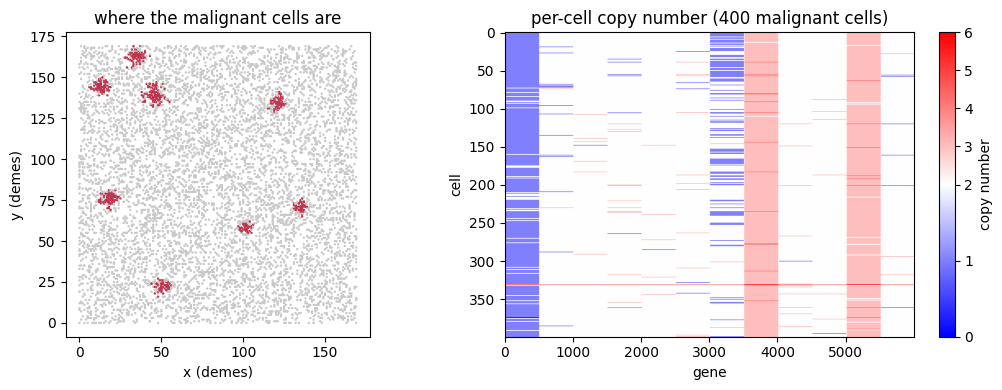

In [2]:
gid = cd["cell_type"]["cell_id"].astype(str).values
types = np.array([tumor.genotypes[g].type if g in tumor.genotypes else "?" for g in gid])
is_cancer = types == "cancer"
cnv = cd["cell_cnv"].values

print(f"cells: {len(types):,}   malignant {is_cancer.sum():,}   normal {(~is_cancer).sum():,} "
      f"(purity {is_cancer.mean():.1%})")
print(f"genome: {cnv.shape[1]:,} genes over {tumor.n_segments} segments")
print("\ncell types present:", ", ".join(f"{t} {int((types==t).sum()):,}"
                                          for t in sorted(set(types))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
crd = cd["cell_crd"]
axes[0].scatter(crd["col"], crd["row"], c=np.where(is_cancer, "#c1344e", "#c9c9c9"),
                s=3, linewidths=0)
axes[0].set_title("where the malignant cells are"); axes[0].set_aspect("equal")
axes[0].set_xlabel("x (demes)"); axes[0].set_ylabel("y (demes)")

# Copy number is a DIVERGING quantity around the diploid baseline, so it gets a diverging map
# centred at 2 — and the scale never goes below zero, because negative copy number is not a thing.
from matplotlib.colors import TwoSlopeNorm
im = axes[1].imshow(cnv[is_cancer][:400], aspect="auto", cmap="bwr",
                    norm=TwoSlopeNorm(vcenter=2.0, vmin=0.0, vmax=max(4.0, cnv.max())))
axes[1].set_title("per-cell copy number (400 malignant cells)")
axes[1].set_xlabel("gene"); axes[1].set_ylabel("cell")
fig.colorbar(im, ax=axes[1], label="copy number")
fig.tight_layout()

## The four datasets, and what each tool is allowed to see

`make_analysis_data.py` turns a tumour like the one above into plain tables. The split is the point:
the tool reads the left column, and the right column is opened only once the tool has committed to an
answer.

| dataset | what the tool reads | ground truth, held back |
|---|---|---|
| `clonealign` | scRNA counts (cells × genes), clone copy number (genes × clones) | each cell's true clone |
| `numbat` | expression counts, a normal reference, phased allele counts, gene annotation | malignant vs normal, and each cell's clone |
| `rctd` | a Visium section (counts + coordinates) and a paired scRNA reference | the true cell-type proportion of every spot |
| `treemhn` | one mutation tree per patient | the planted precedence network the cohort was grown under |

Each dataset also ships a `meta.json` recording the shape of the problem and the **baselines that
make a score readable** — chance, and the majority-class rate. A method that beats chance but not
the majority baseline has not done anything useful, and the number alone will not tell you that.

In [3]:
import json
DATA = os.path.join("..", "analysis_data")
if not os.path.isdir(DATA):
    print("datasets not generated yet — run:  python validation/make_analysis_data.py")
else:
    man = json.load(open(os.path.join(DATA, "manifest.json")))
    for name, m in man["datasets"].items():
        keep = {k: v for k, v in m.items()
                if k in ("n_cells", "n_genes", "n_clones", "n_spots", "n_patients",
                         "chance_baseline", "majority_baseline", "spot_purity_mean",
                         "frac_spots_multitype", "cells_per_spot_mean")}
        pretty = ", ".join(f"{k}={v:,}" if isinstance(v, int) else f"{k}={v:.2f}"
                           for k, v in keep.items())
        print(f"  {name:<12} {pretty}")

  rctd         n_spots=2,542, cells_per_spot_mean=4.89, spot_purity_mean=0.72, frac_spots_multitype=0.75
  clonealign   n_cells=1,501, n_genes=6,000, n_clones=4, majority_baseline=0.49, chance_baseline=0.25
  numbat       n_clones=4, n_cells=1,677, n_genes=6,000
  treemhn      n_patients=36


## Reading a score honestly

Two habits carried through every notebook in this section, both learned from results that looked
fine and were not:

**Report the baseline, not just the score.** A clone-assignment accuracy of 0.67 sounds reasonable
until you notice the largest clone holds 70% of the cells. Every scoring cell prints chance and
majority beside the result.

**Report a threshold-free measure too.** Accuracy depends on where a cut-off falls and on how
imbalanced the classes are; AUC and ARI do not. A method can rank cells correctly — real, usable
signal — and still lose on hard assignment. Reporting only the first number would call that a
failure.